🤖 Random Forest Model Accuracy: 80.45%

📋 Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



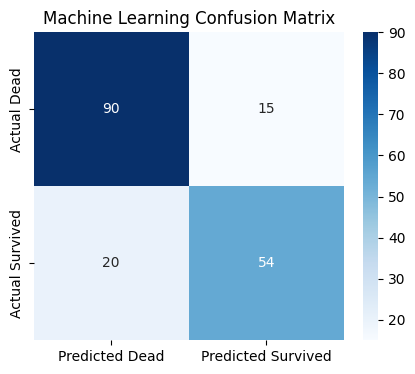

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv('/Titanic-Dataset.csv')

# 2. Preprocess Data (Cleaning missing values & converting text to numbers)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Convert text 'Sex' column into numeric: male = 0, female = 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Select our training features (X) and target variable (y)
# We drop text columns like Name, Ticket, Cabin, etc. because ML models only take numbers.
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = df['Survived']

# 3. Split into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Random Forest Classifier Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Make Predictions and print out the Performance Metrics
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("="*40)
print(f"🤖 Random Forest Model Accuracy: {accuracy * 100:.2f}%")
print("="*40)
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# 6. Level Up: Plot a Confusion Matrix Heatmap to see exactly where it guessed right/wrong
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Dead', 'Predicted Survived'],
            yticklabels=['Actual Dead', 'Actual Survived'])
plt.title('Machine Learning Confusion Matrix')
plt.show()